# 04 - Assumptions, validation, and leakage checks

A Cox model can look professional while being wrong. This notebook teaches the checks that stop that from happening.

We will look at:

- Held-out concordance.
- Proportional-hazards diagnostics.
- Horizon calibration.
- A deliberate leakage example.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

def find_intro_dir():
    cwd = Path.cwd()
    if cwd.name == "survival-analysis-intro":
        return cwd
    if cwd.name == "notebooks" and cwd.parent.name == "survival-analysis-intro":
        return cwd.parent
    candidate = cwd / "survival-analysis-intro"
    if candidate.exists():
        return candidate
    return cwd

INTRO_DIR = find_intro_dir()
DATA_DIR = INTRO_DIR / "data"
OUTPUT_DIR = INTRO_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

In [2]:
from sklearn.model_selection import train_test_split
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test

churn = pd.read_csv(DATA_DIR / "service_churn_drivers.csv")
model_df = pd.get_dummies(
    churn.drop(columns=["customer_id"]),
    columns=["plan", "industry"],
    drop_first=True,
)

train_df, test_df = train_test_split(
    model_df,
    test_size=0.25,
    random_state=7,
    stratify=model_df["churn_observed"],
)

cph = CoxPHFitter(penalizer=0.03)
cph.fit(train_df, duration_col="duration_days", event_col="churn_observed")

print("Train concordance:", round(cph.concordance_index_, 3))
print("Test concordance:", round(cph.score(test_df, scoring_method="concordance_index"), 3))

Train concordance: 0.721
Test concordance: 0.707


## Check 1: proportional hazards

The Cox model assumes a feature has a roughly constant multiplicative effect over time.

Example:

> If training completion reduces churn hazard by 30%, that ratio is roughly similar early and late in the timeline.

The diagnostic below is a screen, not a courtroom verdict. Small p-values mean "look closer."

In [3]:
ph = proportional_hazard_test(cph, train_df, time_transform="rank")
ph.summary.sort_values("p").head(10).round(4)

,test_statistic,p,-log2(p)
discount_pct,6.2365,0.0125,6.3203
login_days_30,2.0624,0.1510,2.7276
plan_Pro,1.5415,0.2144,2.2217
support_tickets_30,0.6809,0.4093,1.2888
monthly_fee,0.5106,0.4749,1.0743
training_completed,0.3402,0.5597,0.8373
industry_Retail,0.3227,0.5700,0.8110
seats,0.1493,0.6992,0.5163
industry_SaaS,0.1316,0.7168,0.4804
industry_Manufacturing,0.0427,0.8363,0.2579


## Check 2: calibration at a business horizon

Concordance checks ranking. A business often also asks:

> If we say a group has 30% churn risk by day 180, does about 30% churn by day 180?

For a fair observed-vs-predicted comparison at a fixed horizon, remove rows censored before that horizon. We cannot know whether those rows would have churned before the horizon.

In [4]:
horizon = 180
X_test = test_df.drop(columns=["duration_days", "churn_observed"])
predicted_churn_risk = 1 - cph.predict_survival_function(X_test, times=[horizon]).T[horizon]

calibration = test_df[["duration_days", "churn_observed"]].copy()
calibration["predicted_churn_risk_180d"] = predicted_churn_risk.values
calibration["observed_by_180d_known"] = (calibration["duration_days"] >= horizon) | (
    (calibration["duration_days"] < horizon) & calibration["churn_observed"].eq(1)
)
calibration = calibration[calibration["observed_by_180d_known"]].copy()
calibration["actual_churn_by_180d"] = (
    calibration["churn_observed"].eq(1) & (calibration["duration_days"] <= horizon)
).astype(int)
calibration["risk_decile"] = pd.qcut(
    calibration["predicted_churn_risk_180d"],
    q=10,
    duplicates="drop",
)

cal_table = calibration.groupby("risk_decile", observed=True).agg(
    n=("actual_churn_by_180d", "size"),
    predicted_churn=("predicted_churn_risk_180d", "mean"),
    actual_churn=("actual_churn_by_180d", "mean"),
).reset_index()

cal_table[["n", "predicted_churn", "actual_churn"]].round(3)

,n,predicted_churn,actual_churn
0,37,0.108,0.081
1,37,0.168,0.216
2,37,0.217,0.189
3,37,0.266,0.324
4,37,0.332,0.351
5,36,0.434,0.417
6,37,0.517,0.432
7,37,0.600,0.568
8,37,0.699,0.757
9,37,0.822,0.865


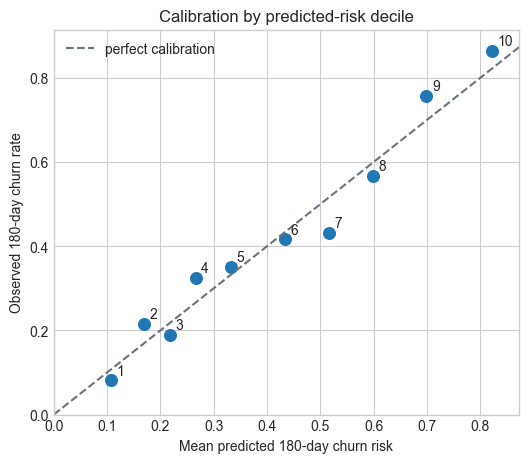

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], linestyle="--", color="#6B7280", label="perfect calibration")
ax.scatter(cal_table["predicted_churn"], cal_table["actual_churn"], s=70)
for i, row in cal_table.iterrows():
    ax.annotate(str(i + 1), (row["predicted_churn"], row["actual_churn"]), xytext=(4, 4), textcoords="offset points")
ax.set_xlim(0, max(0.65, cal_table["predicted_churn"].max() + 0.05))
ax.set_ylim(0, max(0.65, cal_table["actual_churn"].max() + 0.05))
ax.set_xlabel("Mean predicted 180-day churn risk")
ax.set_ylabel("Observed 180-day churn rate")
ax.set_title("Calibration by predicted-risk decile")
ax.legend()
plt.show()

## Check 3: leakage

Leakage means a feature knows something from after the prediction moment.

To make the danger obvious, we will create a forbidden feature from the target itself. It is intentionally bad practice. Watch what happens to the test metric.

In [6]:
leaky_df = model_df.copy()
leaky_df["future_knows_active_after_180d"] = (
    (leaky_df["duration_days"] > 180) | leaky_df["churn_observed"].eq(0)
).astype(int)

train_leaky, test_leaky = train_test_split(
    leaky_df,
    test_size=0.25,
    random_state=7,
    stratify=leaky_df["churn_observed"],
)

leaky_cph = CoxPHFitter(penalizer=0.03)
leaky_cph.fit(train_leaky, duration_col="duration_days", event_col="churn_observed")

pd.DataFrame(
    {
        "model": ["clean_features_only", "with_forbidden_future_feature"],
        "test_concordance": [
            cph.score(test_df, scoring_method="concordance_index"),
            leaky_cph.score(test_leaky, scoring_method="concordance_index"),
        ],
    }
).round(3)

,model,test_concordance
0,clean_features_only,0.707
1,with_forbidden_future_feature,0.864


## A practical review checklist

Before trusting a survival model, ask:

- Was time zero defined before all predictors?
- Were censored rows treated as censored, not as permanent non-events?
- Are train/test splits done by entity and, when relevant, by time?
- Are early-stopping, tuning, and threshold choices made without looking at the test set?
- Do the survival probabilities decrease over time?
- Are predictions stated as conditional on being at risk at the prediction moment?
- Did we check proportional hazards or choose a model that does not need that assumption?

This is the difference between a demo and work you can defend.